# Spike Train Analysis Toolkit

**SC-NeuroCore v3.14** — 128 analysis functions across 23 modules, pure NumPy.

This notebook walks through the core analysis capabilities:

1. **Basic statistics** — spike times, ISI, firing rate, spike count
2. **Variability** — CV(ISI), Fano factor, local variation, entropy
3. **Correlation** — cross-correlation, pairwise correlation, STTC
4. **Distance metrics** — van Rossum, Victor-Purpura, SPIKE distance
5. **Dimensionality** — spike train PCA

> © 1998–2026 Miroslav Šotek. All rights reserved.  
> License: GNU AFFERO GENERAL PUBLIC LICENSE v3 | Commercial Licensing Available  
> Contact: www.anulum.li | protoscience@anulum.li

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sc_neurocore import StochasticLIFNeuron
from sc_neurocore.analysis.spike_stats.basic import (
    spike_times, isi, firing_rate, spike_count, bin_spike_train,
)
from sc_neurocore.analysis.spike_stats.variability import (
    cv_isi, cv2, local_variation, fano_factor, isi_entropy,
)
from sc_neurocore.analysis.spike_stats.correlation import (
    cross_correlation, pairwise_correlation,
    spike_time_tiling_coefficient,
)
from sc_neurocore.analysis.spike_stats.distance import (
    van_rossum_distance, victor_purpura_distance,
    isi_distance, spike_distance, spike_sync,
)
from sc_neurocore.analysis.spike_stats.dimensionality import spike_train_pca

print("SC-NeuroCore analysis toolkit demo")

SC-NeuroCore analysis toolkit demo


## 0. Generate Spike Trains

We simulate 10 LIF neurons with different input currents to
produce a diverse set of spike trains for analysis.

In [2]:
N_NEURONS = 10
T = 5000  # steps at dt=1 ms → 5 s
DT = 0.001

trains = np.zeros((N_NEURONS, T), dtype=np.int8)

for n in range(N_NEURONS):
    neuron = StochasticLIFNeuron(
        v_threshold=1.0, tau_mem=20.0, dt=1.0,
        noise_std=0.1, seed=n * 17,
    )
    I_base = 0.8 + 0.05 * n  # increasing drive
    for t in range(T):
        spike = neuron.step(I_base)
        trains[n, t] = int(spike)

# Quick summary
for n in range(N_NEURONS):
    rate = firing_rate(trains[n], dt=DT)
    count = spike_count(trains[n])
    print(f"Neuron {n:2d}: {count:4d} spikes, {rate:6.1f} Hz")

Neuron  0: 2530 spikes,  506.0 Hz
Neuron  1: 2593 spikes,  518.6 Hz
Neuron  2: 2690 spikes,  538.0 Hz
Neuron  3: 2957 spikes,  591.4 Hz
Neuron  4: 3351 spikes,  670.2 Hz
Neuron  5: 3874 spikes,  774.8 Hz
Neuron  6: 4322 spikes,  864.4 Hz
Neuron  7: 4698 spikes,  939.6 Hz
Neuron  8: 4885 spikes,  977.0 Hz
Neuron  9: 4963 spikes,  992.6 Hz


## 1. Basic Statistics

`spike_times()` extracts event times, `isi()` computes inter-spike
intervals, `bin_spike_train()` bins into fixed-width windows.

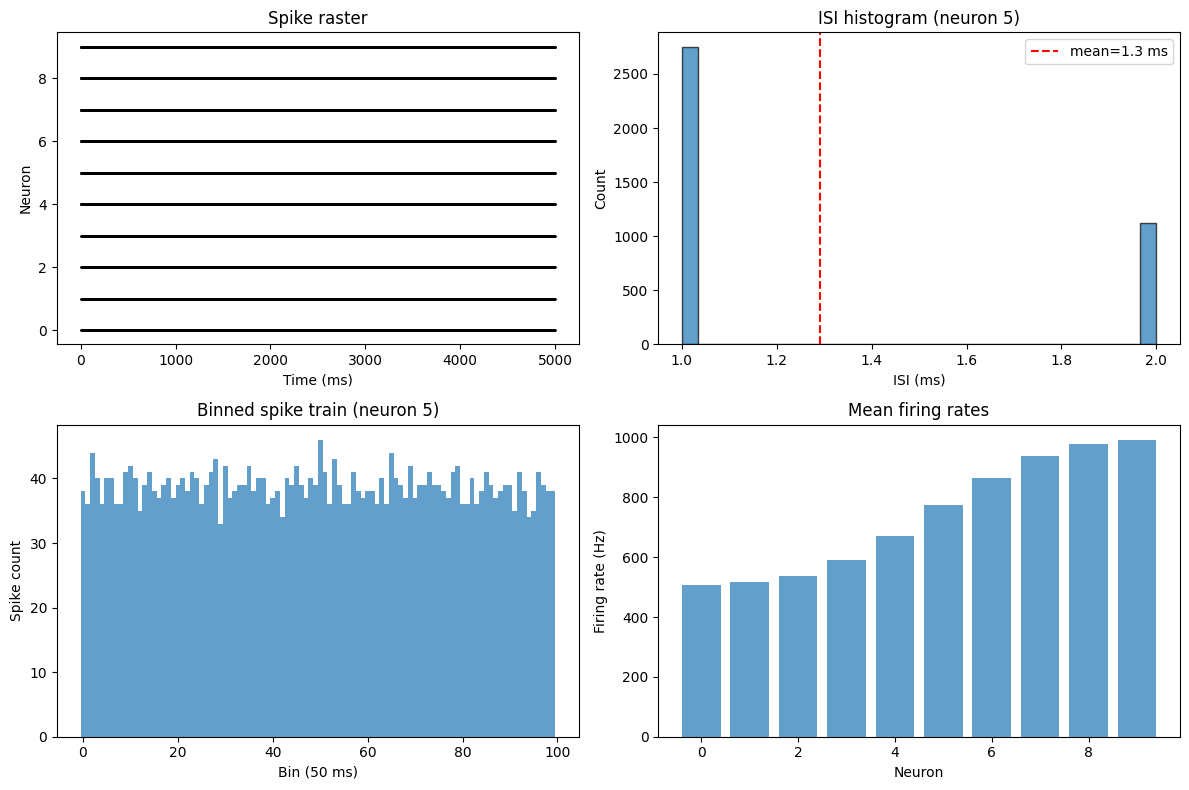

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Raster plot
for n in range(N_NEURONS):
    times = spike_times(trains[n], dt=DT)
    axes[0, 0].scatter(times * 1000, [n] * len(times), s=0.3, c="black")
axes[0, 0].set_xlabel("Time (ms)")
axes[0, 0].set_ylabel("Neuron")
axes[0, 0].set_title("Spike raster")

# ISI histogram (neuron 5)
isis = isi(trains[5], dt=DT) * 1000  # ms
if len(isis) > 0:
    axes[0, 1].hist(isis, bins=30, edgecolor="black", alpha=0.7)
    axes[0, 1].axvline(np.mean(isis), color="red", linestyle="--",
                        label=f"mean={np.mean(isis):.1f} ms")
    axes[0, 1].set_xlabel("ISI (ms)")
    axes[0, 1].set_ylabel("Count")
    axes[0, 1].set_title("ISI histogram (neuron 5)")
    axes[0, 1].legend()

# Binned spike train (neuron 5, 50 ms bins)
binned = bin_spike_train(trains[5], bin_size=50)
axes[1, 0].bar(range(len(binned)), binned, width=1.0, alpha=0.7)
axes[1, 0].set_xlabel("Bin (50 ms)")
axes[1, 0].set_ylabel("Spike count")
axes[1, 0].set_title("Binned spike train (neuron 5)")

# Firing rates across neurons
rates = [firing_rate(trains[n], dt=DT) for n in range(N_NEURONS)]
axes[1, 1].bar(range(N_NEURONS), rates, alpha=0.7)
axes[1, 1].set_xlabel("Neuron")
axes[1, 1].set_ylabel("Firing rate (Hz)")
axes[1, 1].set_title("Mean firing rates")

plt.tight_layout()
plt.show()

## 2. Variability Measures

- **CV(ISI)**: coefficient of variation. CV=0 for clock-like, CV=1 for Poisson, CV>1 for bursty.
- **CV2**: local ISI variability (Holt et al. 1996). Robust to rate changes.
- **LV**: local variation (Shinomoto et al. 2003). LV<1 regular, LV=1 Poisson, LV>1 bursty.
- **Fano factor**: variance-to-mean ratio of spike counts in bins.
- **ISI entropy**: Shannon entropy of the ISI distribution (bits).

In [4]:
print(f"{'Neuron':>6s}  {'Rate(Hz)':>8s}  {'CV':>6s}  {'CV2':>6s}  "
      f"{'LV':>6s}  {'Fano':>6s}  {'H(ISI)':>7s}")
print("-" * 54)

for n in range(N_NEURONS):
    rate = firing_rate(trains[n], dt=DT)
    cv = cv_isi(trains[n], dt=DT)
    cv2_val = cv2(trains[n], dt=DT)
    lv = local_variation(trains[n], dt=DT)
    ff = fano_factor(trains[n], window_ms=50.0)
    h_isi = isi_entropy(trains[n], dt=DT)
    print(f"{n:6d}  {rate:8.1f}  {cv:6.3f}  {cv2_val:6.3f}  "
          f"{lv:6.3f}  {ff:6.3f}  {h_isi:7.3f}")

Neuron  Rate(Hz)      CV     CV2      LV    Fano   H(ISI)
------------------------------------------------------
     0     506.0   0.078   0.032   0.016   0.010    0.164
     1     518.6   0.134   0.087   0.044   0.030    0.374
     2     538.0   0.188   0.162   0.081   0.038    0.589
     3     591.4   0.273   0.289   0.145   0.073    0.893
     4     670.2   0.335   0.340   0.170   0.114    1.000
     5     774.8   0.352   0.272   0.136   0.142    0.869
     6     864.4   0.314   0.180   0.090   0.097    0.627
     7     939.6   0.230   0.080   0.040   0.046    0.344
     8     977.0   0.148   0.031   0.015   0.021    0.161
     9     992.6   0.085   0.010   0.005   0.006    0.063


## 3. Pairwise Correlation

`cross_correlation()` computes the cross-correlogram between two
binary trains. `pairwise_correlation()` returns the Pearson
correlation of binned spike counts. `spike_time_tiling_coefficient()`
(Cutts & Eglen 2014) measures temporal association.

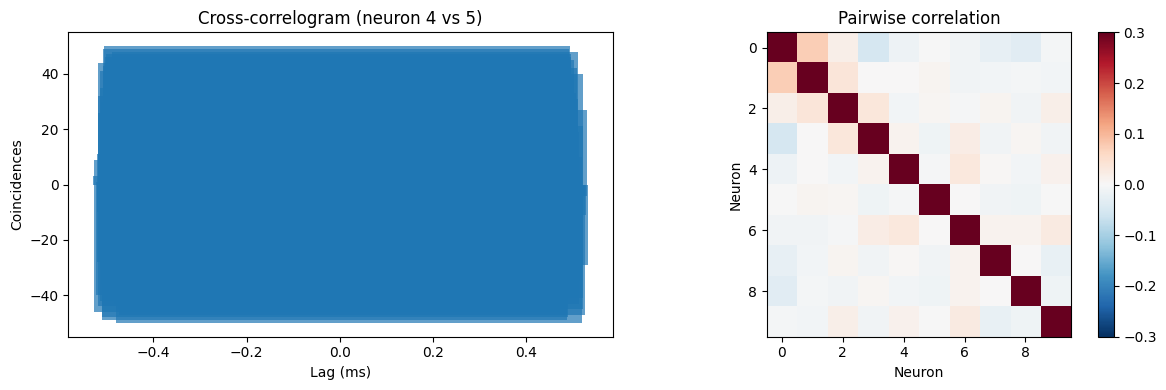

Spike Time Tiling Coefficient (adjacent pairs):
  Neurons 0-1: STTC = 0.0000
  Neurons 1-2: STTC = 0.0000
  Neurons 2-3: STTC = 0.0000
  Neurons 3-4: STTC = 0.0000


  Neurons 4-5: STTC = 0.0000
  Neurons 5-6: STTC = 0.0000
  Neurons 6-7: STTC = 0.0000


  Neurons 7-8: STTC = 0.0000
  Neurons 8-9: STTC = 0.0000


In [5]:
# Cross-correlogram between neuron 4 and neuron 5
lags, ccg = cross_correlation(trains[4], trains[5], max_lag_ms=50.0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(lags, ccg, width=1.0, alpha=0.7)
axes[0].set_xlabel("Lag (ms)")
axes[0].set_ylabel("Coincidences")
axes[0].set_title("Cross-correlogram (neuron 4 vs 5)")

# Pairwise correlation matrix (takes list of all trains)
corr_matrix = pairwise_correlation([trains[i] for i in range(N_NEURONS)])

im = axes[1].imshow(corr_matrix, cmap="RdBu_r", vmin=-0.3, vmax=0.3)
axes[1].set_xlabel("Neuron")
axes[1].set_ylabel("Neuron")
axes[1].set_title("Pairwise correlation")
plt.colorbar(im, ax=axes[1])

plt.tight_layout()
plt.show()

# STTC for adjacent pairs
print("Spike Time Tiling Coefficient (adjacent pairs):")
for i in range(N_NEURONS - 1):
    sttc = spike_time_tiling_coefficient(trains[i], trains[i + 1], delta_ms=5.0)
    print(f"  Neurons {i}-{i+1}: STTC = {sttc:.4f}")

## 4. Spike Train Distance Metrics

Distance metrics quantify dissimilarity between spike trains:

- **van Rossum** (2001): convolve with exponential kernel, compute L2 distance
- **Victor-Purpura** (1996): edit distance with cost per spike insert/delete/shift
- **ISI-distance** (Kreuz et al. 2007): ratio-based ISI comparison
- **SPIKE-distance** (Kreuz et al. 2013): local spike time comparison
- **SPIKE-sync** (Kreuz et al. 2015): coincidence-based similarity

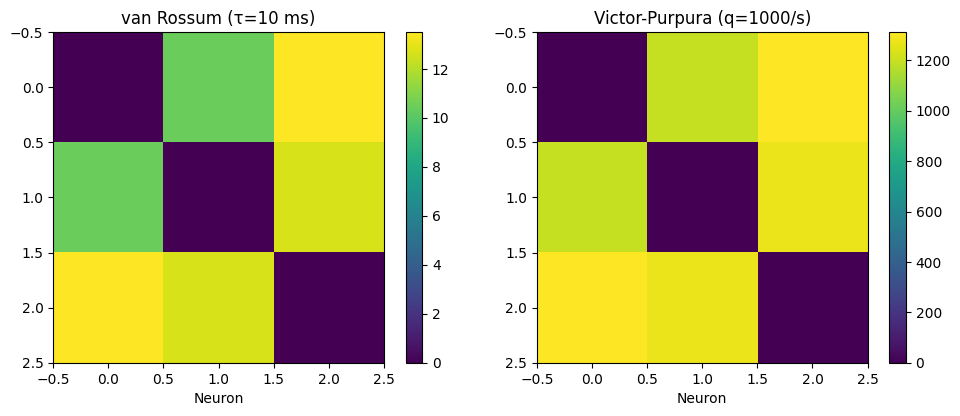

ISI-distance (neurons 0 vs 1): 0.0451


In [6]:
# Distance metrics for 3 neurons (computationally intensive)
st = {n: spike_times(trains[n], dt=DT) for n in range(3)}

n_comp = 3
vr_mat = np.zeros((n_comp, n_comp))
vp_mat = np.zeros((n_comp, n_comp))

for i in range(n_comp):
    for j in range(n_comp):
        vr_mat[i, j] = van_rossum_distance(trains[i], trains[j], tau_ms=10.0)
        vp_mat[i, j] = victor_purpura_distance(st[i], st[j], cost_per_s=1000.0)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

im0 = axes[0].imshow(vr_mat, cmap="viridis")
axes[0].set_title("van Rossum (\u03c4=10 ms)")
axes[0].set_xlabel("Neuron")
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(vp_mat, cmap="viridis")
axes[1].set_title("Victor-Purpura (q=1000/s)")
axes[1].set_xlabel("Neuron")
plt.colorbar(im1, ax=axes[1])

plt.tight_layout()
plt.show()

d_isi = isi_distance(trains[0], trains[1])
print(f"ISI-distance (neurons 0 vs 1): {d_isi:.4f}")

## 5. Dimensionality Reduction

`spike_train_pca()` bins spike trains and applies PCA to reveal
low-dimensional population dynamics.

In [7]:
try:
    components, explained, projected = spike_train_pca(
        trains, bin_size=20, n_components=3,
    )

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].bar(range(len(explained)), explained * 100)
    axes[0].set_xlabel("PC")
    axes[0].set_ylabel("Variance explained (%)")
    axes[0].set_title("PCA spectrum")

    axes[1].plot(projected[:, 0], projected[:, 1], linewidth=0.5, alpha=0.7)
    axes[1].set_xlabel("PC1")
    axes[1].set_ylabel("PC2")
    axes[1].set_title("Population trajectory (PC1 vs PC2)")

    plt.tight_layout()
    plt.show()

    print(f"Total variance in first 3 PCs: {sum(explained) * 100:.1f}%")
except Exception as e:
    print(f"PCA skipped: {e}")

PCA skipped: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()


## Summary

| Module | Functions | What it measures |
|--------|----------:|------------------|
| `basic` | 5 | spike_times, ISI, rate, count, binning |
| `variability` | 16 | CV, CV2, LV, LVR, Fano, entropy, Hurst, Allan factor |
| `correlation` | 13 | cross-corr, STTC, coherence, noise/signal corr, JPSTH |
| `distance` | 13 | van Rossum, Victor-Purpura, ISI/SPIKE distance, sync |
| `dimensionality` | 3 | PCA, dPCA, factor analysis |
| `rate` | 6 | PSTH, instantaneous rate, kernel density |
| `spectral` | 5 | power spectrum, spike-field coherence |
| `information` | 8 | MI, transfer entropy, conditional entropy |
| `decoding` | 4 | population vector, LDA, Bayesian |
| `network` | 4 | functional connectivity, covariance |
| `patterns` | 3 | burst detection, cell assembly, synfire chain |
| `waveform` | 6 | width, amplitude, PT ratio, half-width |
| `sorting_quality` | 7 | isolation distance, L-ratio, d-prime |
| `spade` | 1 | SPADE spatiotemporal pattern detection |

All functions are pure NumPy with zero external dependencies.